<a href="https://colab.research.google.com/github/ruy00803/Baseball-player-Draft-predict-score/blob/main/Baseball-player-draft%20%E3%82%B3%E3%83%B3%E3%83%9A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install category_encoders
!pip install optuna

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from category_encoders import TargetEncoder
import optuna
import lightgbm as lgb

In [ ]:
train=pd.read_csv('/content/train (1).csv')
test=pd.read_csv('/content/test (1).csv')

In [ ]:
#特徴量作成
train=train.drop(columns=['Id'])
test=test.drop(columns=['Id'])
#欠損フラグの作成
train['Age_missing']=train['Age'].isnull().astype(int)
test["Age_missing"]=test['Age'].isnull().astype(int)
#各能力での特徴量
train['Power_Index'] = train['Bench_Press_Reps'] * train['Weight']  # 筋力×体重
train['Jump_Index'] = train['Vertical_Jump'] + train['Broad_Jump']
train['Speed_Agility_Index'] = train['Sprint_40yd'] + train['Shuttle'] + train['Agility_3cone']
test['Power_Index'] = test['Bench_Press_Reps'] * test['Weight']
test['Jump_Index'] = test['Vertical_Jump'] + test['Broad_Jump']
test['Speed_Agility_Index']= test['Sprint_40yd'] + test['Shuttle'] + test['Agility_3cone']

# school column
train['new_school_column_oof']=np.nan
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

for i, (train_idx, valid_idx) in enumerate(skf.split(train, train['Drafted'])):
  X_train_fold, X_valid_fold=train.iloc[train_idx], train.iloc[valid_idx]
  #ここで、X_train_foldだけで統計量の計算を行う
  school_draft_rates=X_train_fold.groupby('School')['Drafted'].mean()
  school_counts=X_train_fold['School'].value_counts()

  school_scores=(1+school_draft_rates)**school_counts

  #validにマッピング
  valid_scores=X_valid_fold['School'].map(school_scores)
  train.loc[valid_idx,'new_school_column_oof']=valid_scores


 #テストデータ用の特徴量作成
school_draft_rates_full=train.groupby('School')['Drafted'].mean()
school_counts_full=train['School'].value_counts()
school_scores_full = (1 + school_draft_rates_full) ** school_counts_full

test['new_school_column']=test['School'].map(school_scores_full)
#school delete
train.drop(columns='School',inplace=True)
test.drop(columns='School',inplace=True)
 #position target encoder
train['Position']=train['Position'].astype(str)
test['Position']=test['Position'].astype(str)
#copy
train_encoded=train.copy()
test_encoded=test.copy()
#初期化
test_encoded['Position']=0.0
#smoothing パラメータ
cat_cols = ['Position']
m=20.0
skf=StratifiedKFold(n_splits=5, shuffle=True,random_state=42)
for train_idx, valid_idx in skf.split(train, train['Drafted']):
  X_train=train.iloc[train_idx]
  X_valid=train.iloc[valid_idx]

  encoder=TargetEncoder(cols=['Position'],smoothing=m)
  encoder.fit(X_train[cat_cols], X_train['Drafted'])

  train_encoded.loc[valid_idx, cat_cols] = encoder.transform(X_valid[cat_cols])
  test_encoded[cat_cols] += encoder.transform(test[cat_cols]) / skf.n_splits
#position
train_encoded.rename(columns={'Position':'Position_TE'},inplace=True)
test_encoded.rename(columns={'Position':'Position_TE'},inplace=True)
#positionごとの身体能力スコアの作成
train_encoded['Speed_TE'] = train_encoded['Sprint_40yd'] * train_encoded['Position_TE']
train_encoded['Bench_TE'] = train_encoded['Bench_Press_Reps'] * train_encoded['Position_TE']
train_encoded['Shuttle_TE'] = train_encoded['Shuttle'] * train_encoded['Position_TE']

test_encoded['Speed_TE'] = test_encoded['Sprint_40yd'] * test_encoded['Position_TE']
test_encoded['Bench_TE'] = test_encoded['Bench_Press_Reps'] * test_encoded['Position_TE']
test_encoded['Shuttle_TE'] = test_encoded['Shuttle'] * test_encoded['Position_TE']
#BMI
train_encoded['BMI'] = train['Weight'] / (train['Height'] ** 2)
test_encoded['BMI'] = test['Weight'] / (test['Height'] ** 2)
#position_TE*BMI
train_encoded['BMI_TE'] = train_encoded['BMI'] * train_encoded['Position_TE']
test_encoded['BMI_TE'] = test_encoded['BMI'] * test_encoded['Position_TE']

train=train_encoded
test=test_encoded
#float
train['Position_TE'] = train['Position_TE'].astype(float)
train['Speed_TE'] = train['Speed_TE'].astype(float)
train['Bench_TE'] = train['Bench_TE'].astype(float)
train['Shuttle_TE'] = train['Shuttle_TE'].astype(float)

test['Position_TE'] = test['Position_TE'].astype(float)
test['Speed_TE'] = test['Speed_TE'].astype(float)
test['Bench_TE'] = test['Bench_TE'].astype(float)
test['Shuttle_TE'] = test['Shuttle_TE'].astype(float)
#label encoder
label_encoders={}
for c in ['Position_Type','Player_Type']:
  label_encoders[c]=LabelEncoder()
  train[c]=label_encoders[c].fit_transform(train[c].astype(str))
  test[c]=label_encoders[c].transform(test[c].astype(str))
#float
train['Position_TE'] = train['Position_TE'].astype(float)
train['Speed_TE'] = train['Speed_TE'].astype(float)
train['BMI_TE'] = train['BMI_TE'].astype(float)
test['Position_TE'] = test['Position_TE'].astype(float)
test['Speed_TE'] = test['Speed_TE'].astype(float)
test['BMI_TE'] = test['BMI_TE'].astype(float)
train['Position_Type']=train['Position_Type'].astype(float)
test['Position_Type']=test['Position_Type'].astype(float)
train['Player_Type']=train['Player_Type'].astype(float)
test['Player_Type']=test['Player_Type'].astype(float)


In [ ]:
#model :LGBM
X=train.drop('Drafted',axis=1)
y=train['Drafted']

def objective(trial,data_x,data_y):
  params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 1.0, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
    }
  model=lgb.LGBMClassifier(**params)
  cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
  scores=cross_val_score(model,data_x,data_y,cv=cv,scoring='roc_auc')
  auc=scores.mean()
  return auc



# --- 3. Studyの作成と最適化の実行方法を修正 ---
study = optuna.create_study(direction='maximize')

# ★`lambda`式を使って、objective関数にXとyを渡す
study.optimize(lambda trial: objective(trial, X, y), n_trials=50)


# --- 4. 結果の確認 ---
print("\n--- チューニング結果 ---")

print(f"総試行回数: {len(study.trials)}")
# study.best_value に最高のスコアが格納されている
print(f"最高スコア (Mean AUC): {study.best_value:.4f}")


# 4-2. 最適なハイパーパラメータを表示
print("\n最適なハイパーパラメータ:")
# study.best_params に最高のスコアを出したパラメータの組み合わせが辞書形式で格納されている
best_params = study.best_params
for key, value in best_params.items():
    print(f"  {key}: {value}")


# 4-3. (オプション) 最も良かった試行（Trial）の詳細情報を表示
# print("\n最も良かった試行の詳細:")
# print(study.best_trial)


# --- 5. 見つけた最適なパラメータで最終モデルを学習 ---
# チューニングの最終目的は、この強力なモデルを作ること。

print("\n--- 最適なパラメータで最終モデルを学習中... ---")

# 最適なパラメータを使って、新しいモデルを定義
final_model = lgb.LGBMClassifier(**best_params, random_state=42) # random_stateも固定しておく

# 訓練データ全体を使って、最終的なモデルを学習させる
# CVは最適なパラメータを探すためのものだったので、最後は使えるデータ全部で学習。
final_model.fit(X, y)

print("最終モデルの学習が完了しました。")
# この 'final_model' が、データセットに対して最も性能が高いと期待されるモデル。
# この後、未知のテストデータに対する予測にこのモデルを使う。
# 例: test_predictions = final_model.predict_proba(X_test)[:, 1]

[I 2025-07-08 10:22:31,346] A new study created in memory with name: no-name-f0058cd8-9dbb-445c-967c-d79543175e97
[I 2025-07-08 10:22:37,646] Trial 0 finished with value: 0.8228669490382984 and parameters: {'n_estimators': 847, 'learning_rate': 0.012402131476418245, 'num_leaves': 128, 'max_depth': 7, 'lambda_l1': 3.6332020142868436e-08, 'lambda_l2': 2.8302123738870683e-06, 'feature_fraction': 0.4672976033767964, 'bagging_fraction': 0.41897469435339685, 'bagging_freq': 6}. Best is trial 0 with value: 0.8228669490382984.
[I 2025-07-08 10:22:38,770] Trial 1 finished with value: 0.8059292365287618 and parameters: {'n_estimators': 376, 'learning_rate': 0.42522013546821547, 'num_leaves': 147, 'max_depth': 11, 'lambda_l1': 3.770154040280177, 'lambda_l2': 1.148084268422696e-06, 'feature_fraction': 0.5637068732482089, 'bagging_fraction': 0.6605805427442645, 'bagging_freq': 7}. Best is trial 0 with value: 0.8228669490382984.
[I 2025-07-08 10:22:51,544] Trial 2 finished with value: 0.829252533565


--- チューニング結果 ---
総試行回数: 50
最高スコア (Mean AUC): 0.8321

最適なハイパーパラメータ:
  n_estimators: 976
  learning_rate: 0.006437156957832171
  num_leaves: 77
  max_depth: 4
  lambda_l1: 0.16767153290624234
  lambda_l2: 1.558427285525284
  feature_fraction: 0.5046816290335066
  bagging_fraction: 0.6799499956097204
  bagging_freq: 5

--- 最適なパラメータで最終モデルを学習中... ---
最終モデルの学習が完了しました。


In [ ]:
skf=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores=[]
for fold, (train_idx, valid_idx) in enumerate(skf.split(X,y)):
  print(f'Fold {fold+1}')
  X_train, X_valid=X.iloc[train_idx], X.iloc[valid_idx]
  y_train, y_valid=y.iloc[train_idx], y.iloc[valid_idx]

  final_model.fit(X_train, y_train)
  y_valid_pred=final_model.predict_proba(X_valid)[:,1]#[:, 1]：陽性クラス（クラス1）の予測確率のみ取得
  auc=roc_auc_score(y_valid, y_valid_pred)
  auc_scores.append(auc)
  print(f'AUC: {auc:.4f}')

mean_auc = np.mean(auc_scores)
print(f'Mean AUC: {mean_auc:.4f}')

Fold 1
AUC: 0.8034
Fold 2
AUC: 0.8602
Fold 3
AUC: 0.8574
Fold 4
AUC: 0.7990
Fold 5
AUC: 0.8461
Mean AUC: 0.8332


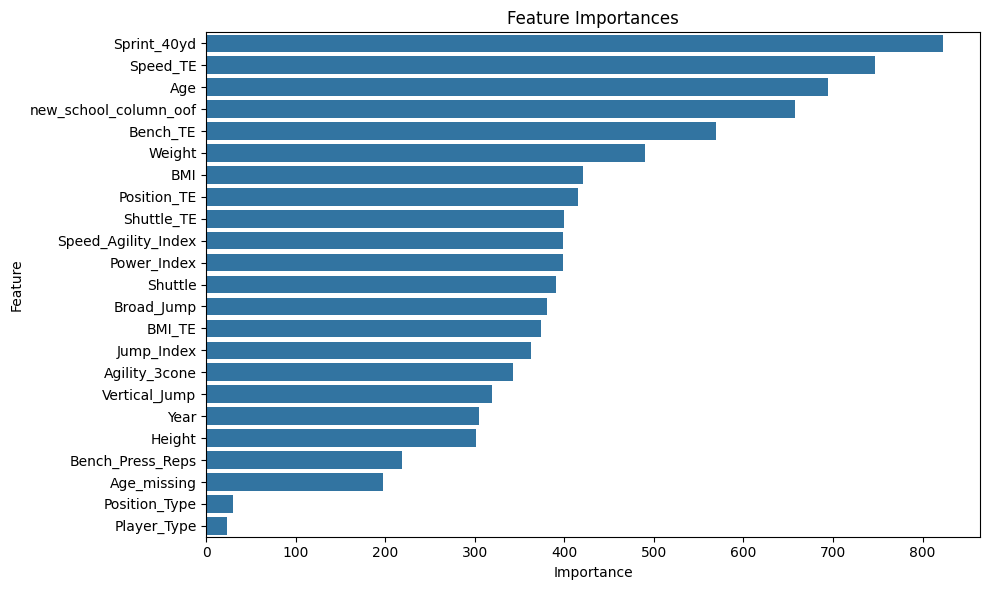

In [ ]:
feature_importances=pd.DataFrame({'feature':X.columns, 'importance':final_model.feature_importances_})
feature_importances=feature_importances.sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importances)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import optuna
import xgboost as xgb  # ★ XGBoostをインポート
from sklearn.model_selection import StratifiedKFold, cross_val_score

# --- 1. データの準備 (LGBM版と共通) ---
X = train.drop('Drafted', axis=1)
y = train['Drafted']

# --- 2. XGBoost用の `objective` 関数を定義 ---
def objective_xgb(trial, data_x, data_y):
    """OptunaでXGBoostのハイパーパラメータをチューニングする関数"""

    # XGBoostのパラメータ探索空間を定義
    # LightGBMと似ているが名前が違うものが多いので注意
    params = {
        'objective': 'binary:logistic', # 目的関数
        'eval_metric': 'auc',           # 評価指標
        'verbosity': 0,                 # ログの非表示
        'use_label_encoder': False,     # DeprecationWarningを避けるためFalseに
        'booster': 'gbtree',            # ブースターの種類

        # チューニング対象のハイパーパラメータ
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0), # LightGBMのbagging_fractionに相当
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0), # LightGBMのfeature_fractionに相当
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True), # 木の複雑度を制御
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True), # L1正則化 (lambda_l1)
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True), # L2正則化 (lambda_l2)
    }

    # ★モデルのクラスを XGBClassifier に変更★
    model = xgb.XGBClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(model, data_x, data_y, cv=cv, scoring='roc_auc')
    auc = scores.mean()

    return auc


# --- 3. XGBoostのチューニングを実行 ---
print("--- XGBoostのハイパーパラメータチューニングを開始します ---")
# 新しいStudyオブジェクトを作成
study_xgb = optuna.create_study(direction='maximize')

# 最適化を実行
study_xgb.optimize(lambda trial: objective_xgb(trial, X, y), n_trials=50) # 試行回数は適宜調整


# --- 4. 結果の確認 ---
print("\n--- XGBoost チューニング結果 ---")
print(f"総試行回数: {len(study_xgb.trials)}")
print(f"最高スコア (Mean AUC): {study_xgb.best_value:.4f}")

print("\n最適なハイパーパラメータ:")
best_params_xgb = study_xgb.best_params
for key, value in best_params_xgb.items():
    print(f"  {key}: {value}")


# --- 5. 見つけた最適なパラメータで最終モデルを学習 ---
print("\n--- 最適なパラメータで最終モデルを学習中... ---")

# ★モデルのクラスを XGBClassifier に変更★
# 最適なパラメータを使って、新しいモデルを定義
final_model_xgb = xgb.XGBClassifier(**best_params_xgb, random_state=42)

# 訓練データ全体を使って、最終的なモデルを学習させる
final_model_xgb.fit(X, y)

print("最終モデルの学習が完了しました。")
# この 'final_model_xgb' が、XGBoostでの最強モデルとなります。

[I 2025-07-08 11:30:01,600] A new study created in memory with name: no-name-f8d73744-b0a4-4341-8ac6-32120eb64d45


--- XGBoostのハイパーパラメータチューニングを開始します ---


[I 2025-07-08 11:30:26,215] Trial 0 finished with value: 0.8247006517643636 and parameters: {'n_estimators': 1344, 'learning_rate': 0.008835647516669745, 'max_depth': 6, 'subsample': 0.5092823144092882, 'colsample_bytree': 0.6148123461161641, 'gamma': 0.9298491801367481, 'reg_alpha': 2.266636652644471e-05, 'reg_lambda': 0.03933439936134521}. Best is trial 0 with value: 0.8247006517643636.
[I 2025-07-08 11:30:32,414] Trial 1 finished with value: 0.7903343106899696 and parameters: {'n_estimators': 636, 'learning_rate': 0.5383423195868219, 'max_depth': 3, 'subsample': 0.7817343002992765, 'colsample_bytree': 0.6015979132855911, 'gamma': 0.004490142302546962, 'reg_alpha': 3.439932503385431e-05, 'reg_lambda': 4.997788902359771e-08}. Best is trial 0 with value: 0.8247006517643636.
[I 2025-07-08 11:30:40,538] Trial 2 finished with value: 0.7809315041628555 and parameters: {'n_estimators': 1887, 'learning_rate': 0.9105935311824067, 'max_depth': 3, 'subsample': 0.6827813281654507, 'colsample_byt


--- XGBoost チューニング結果 ---
総試行回数: 50
最高スコア (Mean AUC): 0.8326

最適なハイパーパラメータ:
  n_estimators: 1825
  learning_rate: 0.0018705261503423878
  max_depth: 6
  subsample: 0.7224933996715324
  colsample_bytree: 0.7976247285759481
  gamma: 0.010974679314679636
  reg_alpha: 0.0049303397616603985
  reg_lambda: 8.246126031921664

--- 最適なパラメータで最終モデルを学習中... ---
最終モデルの学習が完了しました。


In [ ]:
skf=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores=[]
for fold, (train_idx, valid_idx) in enumerate(skf.split(X,y)):
  print(f'Fold {fold+1}')
  X_train, X_valid=X.iloc[train_idx], X.iloc[valid_idx]
  y_train, y_valid=y.iloc[train_idx], y.iloc[valid_idx]

  final_model.fit(X_train, y_train)
  y_valid_pred=final_model_xgb=predict_proba(X_valid)[:,1]#[:, 1]：陽性クラス（クラス1）の予測確率のみ取得
  auc=roc_auc_score(y_valid, y_valid_pred)
  auc_scores.append(auc)
  print(f'AUC: {auc:.4f}')

mean_auc = np.mean(auc_scores)
print(f'Mean AUC: {mean_auc:.4f}')

Fold 1


NameError: name 'predict_proba' is not defined